In [4]:
#### Data loading

import pandas as pd
import os


def track_data(name, df):
    """
    Display the number of rows, number of columns, and column names
    of a DataFrame.
    """
    print("=" * 70)
    print(f"[{name}]")
    print(f"Number of rows: {len(df)}")
    print(f"Number of columns: {df.shape[1]}")
    print(f"Column names: {list(df.columns)}")


# ============================================================
# 1. Load the original datasets
# ============================================================

d_s = pd.read_csv("original/tox24_alogps_oestate.csv")
track_data("d_s: tox24_alogps_oestate.csv immediately after loading", d_s)

d_t = pd.read_csv("original/tox24_challenge_train.csv")
track_data("d_t: tox24_challenge_train.csv immediately after loading", d_t)

d_l = pd.read_csv("original/tox24_challenge_leaderboard.csv")
track_data(
    "d_l: tox24_challenge_leaderboard.csv immediately after loading",
    d_l
)

d_b = pd.read_csv("original/tox24_challenge_test_data.csv")
track_data(
    "d_b: tox24_challenge_test_data.csv immediately after loading",
    d_b
)


# ============================================================
# 2. Combine the training and leaderboard datasets
# ============================================================

stacked = pd.concat(
    [d_t, d_l],
    axis=0,
    ignore_index=True
)
track_data("stacked: immediately after combining train and leaderboard", stacked)

stacked = stacked.sort_values("N").reset_index(drop=True)
track_data("stacked: after sorting by N", stacked)


# ============================================================
# 3. Remove unnecessary columns and rename the target column
# ============================================================

stacked = stacked.drop(
    ["UNIT {TTR binding activity}", "SMILES"],
    axis=1
)
track_data(
    "stacked: after removing the UNIT and SMILES columns",
    stacked
)

stacked = stacked.rename(
    columns={"TTR binding activity": "y"}
)
track_data(
    "stacked: after renaming TTR binding activity to y",
    stacked
)


# ============================================================
# 4. Prepare the blind test dataset
# ============================================================

d_b = d_b.drop(
    ["UNIT {TTR binding activity}", "SMILES"],
    axis=1
)
track_data(
    "d_b: after removing the UNIT and SMILES columns",
    d_b
)

d_b = d_b.rename(
    columns={"TTR binding activity": "y"}
)
track_data(
    "d_b: after renaming TTR binding activity to y",
    d_b
)


# ============================================================
# 5. Extract the SMILES and N columns as index information
# ============================================================

d_s_index = d_s[["SMILES", "N"]].copy()
track_data(
    "d_s_index: after extracting the SMILES and N columns",
    d_s_index
)

print("=" * 70)
print("[Validation of d_s_index]")
print(
    f"Number of duplicate rows based on N: "
    f"{d_s_index.duplicated(subset=['N']).sum()}"
)
print(
    f"Number of duplicate rows based on SMILES: "
    f"{d_s_index.duplicated(subset=['SMILES']).sum()}"
)
print(f"Number of missing N values: {d_s_index['N'].isna().sum()}")
print(
    f"Number of missing SMILES values: "
    f"{d_s_index['SMILES'].isna().sum()}"
)


# ============================================================
# 6. Merge SMILES information into the training dataset
# ============================================================

merged_with_smiles = pd.merge(
    stacked,
    d_s_index,
    on="N",
    how="left",
    validate="many_to_many"
)
track_data(
    "merged_with_smiles: after left-merging stacked with d_s_index",
    merged_with_smiles
)

print("=" * 70)
print("[Results of merging SMILES into the training dataset]")
print(
    "Number of rows for which SMILES could not be assigned: "
    f"{merged_with_smiles['SMILES'].isna().sum()}"
)
print(
    "Number of rows for which SMILES was assigned: "
    f"{merged_with_smiles['SMILES'].notna().sum()}"
)
print(
    "Number of unique SMILES: "
    f"{merged_with_smiles['SMILES'].nunique(dropna=True)}"
)
print(
    "Number of rows containing duplicated SMILES: "
    f"{merged_with_smiles.duplicated(subset=['SMILES'], keep=False).sum()}"
)


# Identify and display all rows containing duplicated SMILES
duplicate_smiles_rows = merged_with_smiles[
    merged_with_smiles.duplicated(
        subset=["SMILES"],
        keep=False
    )
].sort_values("SMILES")

print("=" * 70)
print("[Rows containing duplicated SMILES]")
print(duplicate_smiles_rows.to_string(index=False))


# ============================================================
# 7. Aggregate duplicated compounds by SMILES
#
# The median y value is calculated for each SMILES.
# The minimum N value is retained as the representative N value.
# ============================================================

before_groupby_rows = len(merged_with_smiles)

agg = (
    merged_with_smiles
    .dropna(subset=["SMILES"])
    .groupby("SMILES", as_index=False)
    .agg({
        "y": "median",
        "N": "min"
    })
)
track_data(
    "agg: after aggregation by SMILES",
    agg
)

print("=" * 70)
print("[Change in the number of rows after SMILES aggregation]")
print(f"Number of rows before aggregation: {before_groupby_rows}")
print(f"Number of rows after aggregation: {len(agg)}")
print(
    "Number of rows removed by aggregation: "
    f"{before_groupby_rows - len(agg)}"
)


# ============================================================
# 8. Prepare the final training dataset
# ============================================================

merge_t = (
    agg[["N", "SMILES", "y"]]
    .sort_values("N")
    .reset_index(drop=True)
)
track_data(
    "merge_t: final training dataset",
    merge_t
)

print("=" * 70)
print("[Validation of merge_t]")
print(
    f"Number of unique N values: "
    f"{merge_t['N'].nunique(dropna=True)}"
)
print(
    f"Number of unique SMILES: "
    f"{merge_t['SMILES'].nunique(dropna=True)}"
)
print(f"Number of missing y values: {merge_t['y'].isna().sum()}")
print(
    f"Number of missing SMILES values: "
    f"{merge_t['SMILES'].isna().sum()}"
)


# ============================================================
# 9. Merge SMILES information into the blind test dataset
# ============================================================

before_test_merge_rows = len(d_b)

merge_b = pd.merge(
    d_b,
    d_s_index,
    on="N",
    how="inner",
    validate="many_to_many"
)
track_data(
    "merge_b: immediately after inner-merging d_b with d_s_index",
    merge_b
)

print("=" * 70)
print("[Results of merging SMILES into the blind test dataset]")
print(
    f"Number of blind test rows before merging: "
    f"{before_test_merge_rows}"
)
print(
    f"Number of blind test rows after merging: "
    f"{len(merge_b)}"
)
print(
    "Estimated number of rows lost during merging: "
    f"{before_test_merge_rows - len(merge_b)}"
)

merge_b = (
    merge_b[["N", "SMILES", "y"]]
    .sort_values("N")
    .reset_index(drop=True)
)
track_data(
    "merge_b: final blind test dataset",
    merge_b
)

print("=" * 70)
print("[Validation of merge_b]")
print(
    f"Number of unique N values: "
    f"{merge_b['N'].nunique(dropna=True)}"
)
print(
    f"Number of unique SMILES: "
    f"{merge_b['SMILES'].nunique(dropna=True)}"
)
print(f"Number of missing y values: {merge_b['y'].isna().sum()}")
print(
    f"Number of missing SMILES values: "
    f"{merge_b['SMILES'].isna().sum()}"
)


# ============================================================
# 10. Create the output directory and save the CSV files
# ============================================================

output_folder = "process"
os.makedirs(output_folder, exist_ok=True)

train_output_path = os.path.join(
    output_folder,
    "tox24_t.csv"
)

blind_output_path = os.path.join(
    output_folder,
    "tox24_b.csv"
)

merge_t.to_csv(
    train_output_path,
    index=False
)

merge_b.to_csv(
    blind_output_path,
    index=False
)


# ============================================================
# 11. Display the final results
# ============================================================

print("\n" + "=" * 70)
print("Processing completed")
print("=" * 70)
print(f"Final number of training rows: {len(merge_t)}")
print(f"Final number of blind test rows: {len(merge_b)}")
print(f"Training dataset saved to: {train_output_path}")
print(f"Blind test dataset saved to: {blind_output_path}")
print("=" * 70)

[d_s: tox24_alogps_oestate.csv immediately after loading]
Number of rows: 1512
Number of columns: 368
Column names: ['SMILES', 'N', 'ALogPS_logP', 'ALogPS_logS', 'HALOG', 'MW', 'N.1', 'NA', 'NH', 'O', 'P', 'PSA', 'S', 'SdCH2', 'SdssC', 'Se1C1C4s', 'Se1C2C2ss', 'Se1C2C3sd', 'Se1C2C3ss', 'Se1C3C3ds', 'Se1C3C4ss', 'Se2C1C3s', 'SsCH3', 'SssCH2', 'SsssCH', 'SssssC', 'aCNOS', 'ACCEPTORS', 'RBONDS', 'SaaCH', 'SaasC', 'SdO', 'SdO(ester)', 'Se1C1C3s', 'Se1C1O2s', 'Se1C3Cl1a', 'Se1C3O2as', 'Se1C3O2ds', 'Se1C3O2ss', 'Se2C3O1s', 'SeaC2C2aa', 'SeaC2C3aa', 'SeaC3C3aa', 'SsCl', 'SssO', 'SssO(ester)', 'DONORS', 'Se1C1C2s', 'Se1C2O1s', 'Se1C2O2ss', 'Se1C3O1s', 'SsOH', 'SsOH(alc)', 'Se1C1C3d', 'Se1C2C4ss', 'Se1C4C4ss', 'SdsCH', 'Se1C2C2ds', 'Se2C2C2ss', 'SdO(keto)', 'Se1C2C2dd', 'Se2C2O1s', 'SaaN', 'SaasN', 'Se1C1C3a', 'Se1C2N3sa', 'SeaC3N2aa', 'SeaC3N3aa', 'SeaN2N3aa', 'Se1C1C2d', 'Se1C2C3ds', 'Se1C3C3ss', 'Se2C2C3ss', 'SdO(acid)', 'Se1C2S2ss', 'Se1C3N2as', 'Se1C3O1d', 'Se1C3S2as', 'SsOH(acid)', 'SssNH

In [28]:
####カノニカル化

import pandas as pd
import re
import sys
from canonical_module.desalt import desalt
from canonical_module.neutralize import neutralize_charges
from canonical_module.rdkit_util import bringChargeToTail
from rdkit import Chem

def simplify_charge(smiles):
    pattern = r'\[([^\[\]]*?)([\+\-]{2,})([^\[\]]*?)\]'
    while True:
        matched = re.search(pattern, smiles)
        if matched:
            atom_part = matched.group(1)
            charge_part = matched.group(2)
            remainder_part = matched.group(3)
            charge_count = len(charge_part)
            simplified_charge = f"{charge_part[0]}{charge_count}"
            new_smiles = f"[{atom_part}{simplified_charge}{remainder_part}]"
            smiles = smiles[:matched.start()] + new_smiles + smiles[matched.end():]
        else:
            break
    return smiles

def process_smiles(smiles):
    try:
        smiles = simplify_charge(smiles)
        smiles = bringChargeToTail(smiles)
        smiles = desalt(smiles)
        smiles = neutralize_charges(smiles)
        mol = Chem.MolFromSmiles(smiles)
        smiles = Chem.MolToSmiles(mol)
        return smiles
    except Exception as e:
        print(f"Error processing SMILES '{smiles}': {e}", file=sys.stderr)
        return ""

# 入力ファイルパス（変更して使ってください）
csv_path_t = "process/tox24_t.csv"
csv_path_b = "process/tox24_b.csv"

csv_path_list = [csv_path_t, csv_path_b]
            
for csv_path in csv_path_list:
    # データ読み込み
    data = pd.read_csv(csv_path)

    # 列名チェック
    if 'SMILES' not in data.columns:
        raise ValueError("The CSV file must contain a 'SMILES_s' column.")

    # 各SMILESを処理
    data['SMILES'] = data['SMILES'].apply(process_smiles)

    # 保存先ファイルパス（自動で"_processed"を付ける例）
    output_csv_path = csv_path.replace('.csv', '_c.csv')
    data.to_csv(output_csv_path, index=False)

    print(f"Processed SMILES have been saved to {output_csv_path}")




neutralized_smiles: O=C(O)COc1ccc(Cl)cc1Cl
neutralized_smiles: CCCCC(CC)CCC(CC(C)C)OS(=O)(=O)O
neutralized_smiles: CC1=CC(=O)NS(=O)(=O)O1
neutralized_smiles: Cc1cc(Cl)ccc1OCC(=O)O
neutralized_smiles: Nc1ccc2cc(S(=O)(=O)O)cc(O)c2c1/N=N/c1ccccc1C(F)(F)F
neutralized_smiles: COc1cc(S(=O)(=O)O)c(C)cc1/N=N/c1c(O)ccc2cc(S(=O)(=O)O)ccc12
neutralized_smiles: CCCCCCCCCCCCOCCOS(=O)(=O)O
neutralized_smiles: NC(=O)O
neutralized_smiles: N#CS
neutralized_smiles: O=C(O)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)C(F)(F)F
neutralized_smiles: NS(=O)(=O)O
neutralized_smiles: CC(C)c1c(C(=O)Nc2ccccc2)c(-c2ccccc2)c(-c2ccc(F)cc2)n1CC[C@@H](O)C[C@@H](O)CC(=O)O
neutralized_smiles: O=C(O)c1ccc2c(c1)nc(C(=O)NC1CCN(C3CC3)CC1)n2Cc1cc(-c2ccc(Cl)s2)on1
neutralized_smiles: CCCCc1ccc2cccc(S(=O)(=O)O)c2c1
neutralized_smiles: O=S(=O)(O)c1cc(S(=O)(=O)O)c2c(N=Nc3ccccc3)c(O)ccc2c1
neutralized_smiles: COc1ccc(N=Nc2cc(C)c(N=Nc3ccc(S(=O)(=O)O)cc3)cc2OC)cc1
neutralized_smiles: O=S(=O)(O)c1ccc(N=Nc2c(O)ccc3ccccc23)cc1
neutralized

Processed SMILES have been saved to process/tox24_t_c.csv
Processed SMILES have been saved to process/tox24_b_c.csv


neutralized_smiles: COc1cc(OC)nc(NC(=O)NS(=O)(=O)c2ncccc2OCC(F)(F)F)n1
neutralized_smiles: CN(C)C(=S)S
neutralized_smiles: Cc1cc(S(=O)(=O)O)ccc1/N=N/c1c(O)ccc2ccccc12
neutralized_smiles: Cc1ccc(S(=O)(=O)Oc2ccc(N=Nc3ccc(-c4ccc(N=Nc5c(O)ccc6cc(S(=O)(=O)O)cc(S(=O)(=O)O)c56)c(C)c4)cc3C)cc2)cc1
neutralized_smiles: O=C(O)C1=NN(c2ccc(S(=O)(=O)O)cc2)C(=O)C1/N=N/c1ccc(S(=O)(=O)O)cc1
neutralized_smiles: CCCCc1nc2cccnc2n1Cc1ccc(-c2ccccc2-c2nnn[nH]2)cc1
neutralized_smiles: CCCCCCCCCCCCCCCCCCOS(=O)(=O)O
neutralized_smiles: NC(=O)c1nc(-c2cccc(-c3cc(F)ccc3OCC(F)(F)C(F)(F)F)c2)n[nH]1
neutralized_smiles: O=S(=O)(O)c1cccc2ccccc12
neutralized_smiles: O=Cc1ccccc1S(=O)(=O)O
neutralized_smiles: O=S(=O)(O)c1ccc2ccccc2c1
neutralized_smiles: O=[N+]([O-])c1ccccc1O
neutralized_smiles: CCCCCCCCOS(=O)(=O)O
neutralized_smiles: O=S(=O)(O)OOS(=O)(=O)O
neutralized_smiles: CC(=O)CC(c1ccccc1)c1c(O)c2ccccc2oc1=O
neutralized_smiles: [O-][n+]1ccccc1S


ML_data/folds.pkl に保存しました。


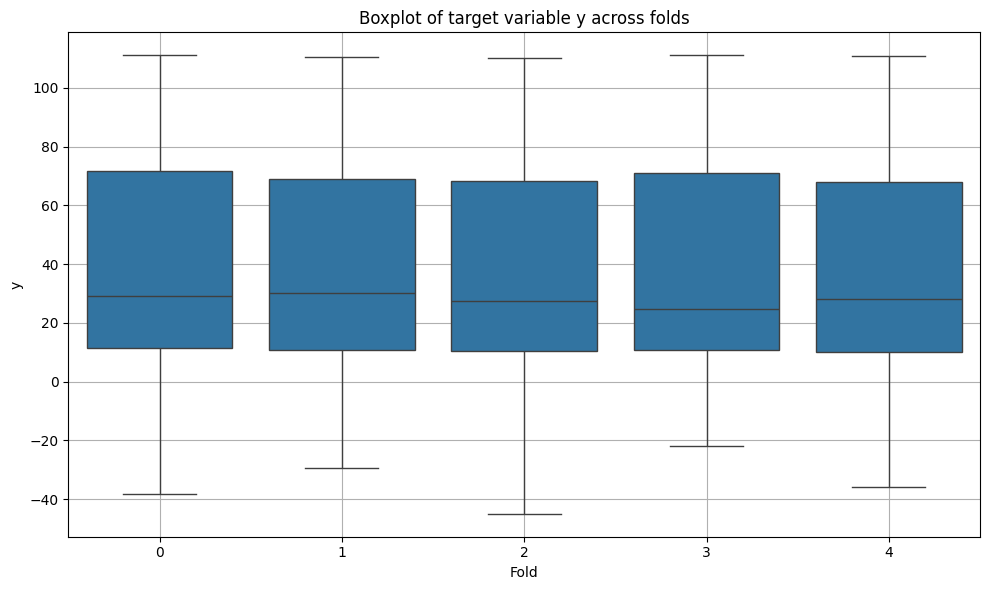

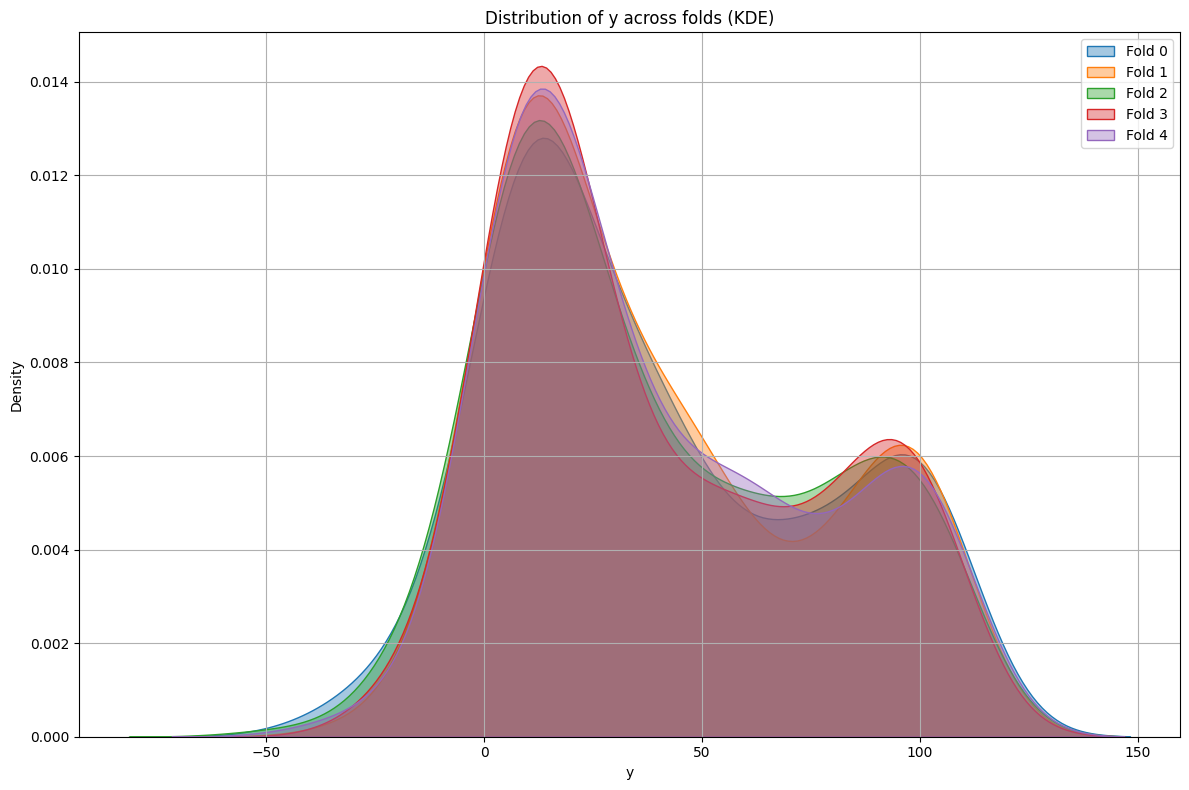

=== 各フォールドごとの y の統計量 ===
      count       mean        std   min     25%        50%        75%  \
fold                                                                    
0     243.0  39.656100  37.031829 -38.3  11.450  29.200000  71.850000   
1     242.0  39.849112  35.667211 -29.5  10.625  30.100000  68.850000   
2     242.0  39.108767  36.471785 -45.0  10.500  27.444158  68.245678   
3     242.0  39.626545  35.737175 -22.0  10.725  24.750000  71.175000   
4     242.0  39.792491  35.808197 -35.9  10.100  28.050000  68.025000   

            max     median  
fold                        
0     111.12188  29.200000  
1     110.40000  30.100000  
2     110.30000  27.444158  
3     111.10000  24.750000  
4     111.00000  28.050000  


In [29]:
####データ分割

import pandas as pd
from sklearn.model_selection import StratifiedKFold
import pickle
import numpy as np
import os
import matplotlib.pyplot as plt
import seaborn as sns

os.makedirs("ML_data", exist_ok = True)

# === 設定 ===
csv_path = 'process/tox24_t.csv'         # CSVファイルのパスを指定
y_column = 'y'                     # y列の名前（連続値）
n_splits = 5                       # 分割数
output_pkl_path = 'ML_data/folds.pkl'     # 出力pklファイル名

# === データ読み込み ===
df = pd.read_csv(csv_path)
y_continuous = df[y_column]

# === y をビン分割して擬似カテゴリ化（層化用）===
# 分位点に基づくビン分け（同数ビン）
y_binned = pd.qcut(y_continuous, q=n_splits, labels=False, duplicates='drop')

# === Stratified 5-fold 分割 ===
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)
fold_dict = {}

for fold, (_, test_idx) in enumerate(skf.split(df, y_binned)):
    for idx in test_idx:
        fold_dict[int(idx)] = {'N': n_splits, 'fold': fold}

# === 保存 ===
with open(output_pkl_path, 'wb') as f:
    pickle.dump(fold_dict, f)

print(f'{output_pkl_path} に保存しました。')

# === 各foldのy値をまとめる ===
df['fold'] = df.index.map(lambda idx: fold_dict[idx]['fold'])

# matplotlibの設定
plt.figure(figsize=(10, 6))

# 箱ひげ図で比較（各フォールドのyの分布）
sns.boxplot(data=df, x='fold', y='y')
plt.title('Boxplot of target variable y across folds')
plt.xlabel('Fold')
plt.ylabel('y')
plt.grid(True)
plt.tight_layout()
plt.show()

# === さらに：ヒストグラムで各foldのy分布を比較したい場合 ===
plt.figure(figsize=(12, 8))
for fold in range(n_splits):
    sns.kdeplot(df[df['fold'] == fold]['y'], label=f'Fold {fold}', fill=True, alpha=0.4)
plt.title('Distribution of y across folds (KDE)')
plt.xlabel('y')
plt.ylabel('Density')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

# 各フォールドごとにyの統計量をまとめる
summary_stats = df.groupby('fold')['y'].describe()
summary_stats['median'] = df.groupby('fold')['y'].median()  # 中央値は describe に含まれないため個別に追加

# 表示
print("=== 各フォールドごとの y の統計量 ===")
print(summary_stats)

# CSVに保存したい場合
summary_stats.to_csv("ML_data/fold_y_statistics.csv")



In [1]:
import pandas as pd
import numpy as np
import random
import pickle
from sklearn.linear_model import LinearRegression # R2計算に引き続き使用
from sklearn.metrics import r2_score
from tqdm import tqdm
from pathlib import Path
import warnings

# SettingWithCopyWarningを無視
pd.options.mode.chained_assignment = None

# --- 定数設定 ---
SEED = 42
R2_THRESHOLD = 0.9 # 新しいR2フィルターの閾値

# --- ファイルパス定義 (pathlibを使用) ---
DATA_DIR = Path('ML_data') # データディレクトリ
# 入力ファイルのパス
D1_INPUT_PATH = DATA_DIR / 'tox24_t_mord.csv'
D2_INPUT_PATH = DATA_DIR / 'tox24_t_c_mord.csv'
# 出力ファイルのパス
PKL_COMMON_DUP = DATA_DIR / 'common_dup.pkl' # d1とd2で完全に一致し、最終的にd1側が選ばれた記述子用
PKL_D1_UNIQUE = DATA_DIR / 'd1_selected.pkl' # d1に固有で最終的に選ばれた記述子用
PKL_D2_UNIQUE = DATA_DIR / 'd2_selected.pkl' # d2に固有で最終的に選ばれた記述子用

# --- シード固定 ---
np.random.seed(SEED)
random.seed(SEED)

# --- 共通前処理関数 ---
def clean_features(df: pd.DataFrame, target_col: str = 'y') -> pd.DataFrame:
    """
    データフレームをクリーニングする関数。
    - "N", "SMILES", 指定されたtarget_col（存在すれば）を削除。
    - 全てのNaNを含む列を削除。
    - ほぼ定数（一意な値が1つ、または2つの値がありそのうち1つがユニークな場合）の列を削除。
    """
    df = df.drop(columns=["N", "SMILES", target_col], errors='ignore')
    df = df.dropna(axis=1, how='all') # 全てがNaNの列を削除
    return df.loc[:, ~df.apply(lambda col: len(col.value_counts()) <= 1 or
                                            (len(col.value_counts()) == 2 and col.value_counts().min() == 1), axis=0)]

# --- 新しいR2フィルター関数 (効率化されたロジック) ---
def apply_fast_r2_filter(X: pd.DataFrame, y: pd.Series, prefix: str, r2_threshold: float) -> list:
    """
    効率的なR2値に基づき、冗長な特徴量をフィルタリングする関数。
    yとのR2でソート後、特徴量間のR2を用いて多重共線性の高い特徴量を削除する。
    """
    print(f"  {prefix}R2フィルター（高速版）を適用中...")
    
    # NaNを含む列を除外 (R2計算のため)
    X_filtered_nan = X.dropna(axis=1)
    
    if X_filtered_nan.empty:
        print(f"  {prefix}R2フィルター: 適用可能な特徴量がありませんでした。")
        return []

    # 1. yとのR2値を計算し、特徴量をソートする
    r2_scores_with_y = {}
    for feature in X_filtered_nan.columns:
        try:
            model = LinearRegression()
            model.fit(X_filtered_nan[[feature]], y)
            y_pred = model.predict(X_filtered_nan[[feature]])
            r2 = r2_score(y, y_pred)
            r2_scores_with_y[feature] = r2
        except ValueError:
            r2_scores_with_y[feature] = -np.inf # 計算できない場合は低い値にする

    # yとのR2値で降順にソートされた特徴量リスト
    sorted_features_by_y_r2 = sorted([item for item in r2_scores_with_y.items() if item[1] >= 0], # R2が負の値は除外
                                     key=lambda item: item[1], reverse=True)
    
    if not sorted_features_by_y_r2:
        print(f"  {prefix}R2フィルター: yとのR2が正の値の特徴量がありませんでした。")
        return []

    sorted_feature_names = [feat for feat, _ in sorted_features_by_y_r2]

    # 2. 特徴量間のR2行列を計算 (全特徴量に対して一度だけ)
    # 選択された特徴量のみでDataFrameを作成
    df_for_r2_matrix = X_filtered_nan[sorted_feature_names]
    
    # 相関行列を計算し、それを二乗してR2行列にする
    with warnings.catch_warnings():
        warnings.simplefilter("ignore", RuntimeWarning) # 0除算によるRuntimeWarningを無視
        corr_matrix = df_for_r2_matrix.corr().abs()
        r2_matrix = corr_matrix**2
    
    # 上三角行列を取得 (対角要素を除く)
    upper = r2_matrix.where(np.triu(np.ones(r2_matrix.shape), k=1).astype(bool))

    to_drop = set()
    selected_features = [] # 最終的に残す特徴量のリスト
    
    # 3. ソートされたリストを走査し、多重共線性の高い特徴量を削除
    pbar = tqdm(sorted_feature_names, desc=f"{prefix}冗長性チェック進行度", leave=False)
    for feature in pbar:
        if feature in to_drop:
            continue # 既に削除対象としてマークされている場合はスキップ
        
        # この特徴量を残す特徴量リストに追加
        selected_features.append(feature)

        # この特徴量とR2閾値を超える相関を持つ他の特徴量を探す
        # upper.loc[feature] は、featureを行とする他の列とのR2値を示すSeries
        high_r2_features = upper.loc[feature][upper.loc[feature] >= r2_threshold].index.tolist()

        # 検出された高相関の特徴量を削除対象に追加
        for col_to_remove in high_r2_features:
            to_drop.add(col_to_remove)
    
    pbar.close()
    print(f"  {prefix}R2フィルター: 元の {X.shape[1]} 個の特徴量から {len(selected_features)} 個に絞り込まれました。")
    return selected_features


# --- データ読み込み ---
try:
    print(f"データファイルを読み込んでいます...")
    d1_all = pd.read_csv(D1_INPUT_PATH)
    d2_all = pd.read_csv(D2_INPUT_PATH)
    print("データ読み込み完了。\n")
except FileNotFoundError as e:
    print(f"エラー: データファイルが見つかりません。")
    print(f"以下のパスにファイルが存在するか確認してください: {D1_INPUT_PATH}, {D2_INPUT_PATH}")
    print(f"詳細: {e}")
    exit() # スクリプトを終了

# 目的変数を取得 (yはd1_allから取得)
y = d1_all['y']
print(f"目的変数 'y' のデータ数: {len(y)}\n")


# --- ステップ0: 前処理済みの特徴量を準備 (分散除去) ---
print("前処理（分散除去）を実行中...")
X1_cleaned = clean_features(d1_all.copy(), target_col='y')
X2_cleaned = clean_features(d2_all.copy(), target_col='y')

# R2フィルターの入力はNaNを含まないことが前提なので、ここでNaNを持つ列を削除
# clean_featuresでもNaNを含む列は削除しているが、念のため
initial_cols_X1 = X1_cleaned.shape[1]
initial_cols_X2 = X2_cleaned.shape[1]
X1_cleaned = X1_cleaned.dropna(axis=1)
X2_cleaned = X2_cleaned.dropna(axis=1)
if X1_cleaned.shape[1] < initial_cols_X1:
    print(f"  d1: NaNを含む列を {initial_cols_X1 - X1_cleaned.shape[1]} 個削除しました。")
if X2_cleaned.shape[1] < initial_cols_X2:
    print(f"  d2: NaNを含む列を {initial_cols_X2 - X2_cleaned.shape[1]} 個削除しました。")
    
print(f"d1の前処理後の特徴量数: {X1_cleaned.shape[1]}")
print(f"d2の前処理後の特徴量数: {X2_cleaned.shape[1]}\n")


# --- ステップ1: d1データ単体での特徴量選択 (R2フィルター - 高速版) ---
print("=== ステップ1: d1データ単体でR2フィルターを実行中... ===")
selected_features_d1_step1 = apply_fast_r2_filter(X1_cleaned, y, "d1: ", R2_THRESHOLD)
print(f"d1単体でR2フィルターにより選択された特徴量数: {len(selected_features_d1_step1)}\n")


# --- ステップ2: d2データ単体での特徴量選択 (R2フィルター - 高速版) ---
print("=== ステップ2: d2データ単体でR2フィルターを実行中... ===")
selected_features_d2_step2 = apply_fast_r2_filter(X2_cleaned, y, "d2: ", R2_THRESHOLD)
print(f"d2単体でR2フィルターにより選択された特徴量数: {len(selected_features_d2_step2)}\n")


# --- ステップ3: d1/d2で選ばれた特徴量を統合し、結合後に完全一致記述子をサーチ ---
print("=== ステップ3: 選ばれた特徴量を統合し、結合後に完全一致記述子をサーチ... ===")

# ステップ1で選ばれたd1の特徴量を抽出
X1_selected_df = X1_cleaned[selected_features_d1_step1].copy()

# ステップ2で選ばれたd2の特徴量を抽出
X2_selected_df = X2_cleaned[selected_features_d2_step2].copy()

# プレフィックスを付ける
X1_selected_df.columns = ['d1_' + col for col in X1_selected_df.columns]
X2_selected_df.columns = ['d2_' + col for col in X2_selected_df.columns]

# 一旦結合し、この結合されたDataFrameで完全一致をサーチ
X_combined_for_search = pd.concat([X1_selected_df, X2_selected_df], axis=1)

print(f"結合された特徴量数（重複あり）: {X_combined_for_search.shape[1]}")

# 結合後のDataFrameで、d1_xxx と d2_xxx の組み合わせで完全に一致するものをサーチ
common_exact_match_descriptors_final = []
# 結合後のDataFrameの列名からベース名を取得
base_names_in_combined = {col.replace('d1_', '').replace('d2_', '') for col in X_combined_for_search.columns}

for base_name in tqdm(sorted(list(base_names_in_combined)), desc="結合後完全一致サーチ"):
    d1_col_name = f'd1_{base_name}'
    d2_col_name = f'd2_{base_name}'

    # d1_側とd2_側の両方が存在し、かつ値が完全に一致する場合
    # .values を使ってNumpy配列で比較することで、Pandasのインデックスアライメント問題を避ける
    if d1_col_name in X_combined_for_search.columns and \
       d2_col_name in X_combined_for_search.columns and \
       np.array_equal(X_combined_for_search[d1_col_name].values, X_combined_for_search[d2_col_name].values):
        common_exact_match_descriptors_final.append(base_name)

print(f"結合後に完全に一致すると判明した記述子数: {len(common_exact_match_descriptors_final)}件\n")

# --- 最終的な選択記述子リストの作成と保存 ---
# d1側の最終選択記述子 (R2フィルターで選択済み)
final_selected_d1_features = [col for col in selected_features_d1_step1 if col not in common_exact_match_descriptors_final]

# d2側の最終選択記述子 (R2フィルターで選択済み)
final_selected_d2_features = [col for col in selected_features_d2_step2 if col not in common_exact_match_descriptors_final]

# 共通で完全に一致する記述子は、d1側から代表として追加
final_selected_common_dup = [col for col in common_exact_match_descriptors_final]

# 最終的に選択された特徴量の特定と保存
selected_common_dup = sorted(list(set(final_selected_common_dup)))
selected_d1_unique = sorted(list(set(final_selected_d1_features)))
selected_d2_unique = sorted(list(set(final_selected_d2_features)))


# 出力ディレクトリが存在しない場合は作成
DATA_DIR.mkdir(parents=True, exist_ok=True)

try:
    print("最終的に選択された記述子を保存中...")
    # 完全に一致した記述子の中で、最終的に選ばれたものを保存
    with open(PKL_COMMON_DUP, "wb") as f:
        pickle.dump(selected_common_dup, f)
    # d1固有で最終的に選ばれたものを保存
    with open(PKL_D1_UNIQUE, "wb") as f:
        pickle.dump(selected_d1_unique, f)
    # d2固有で最終的に選ばれたものを保存
    with open(PKL_D2_UNIQUE, "wb") as f:
        pickle.dump(selected_d2_unique, f)

    print("最終記述子の候補を保存しました：")
    print(f"- {PKL_COMMON_DUP.name} ({len(selected_common_dup)}件): d1とd2で完全に一致し、最終的に選択された記述子（d1側）")
    print(f"- {PKL_D1_UNIQUE.name} ({len(selected_d1_unique)}件): 最終選択されたd1固有の記述子")
    print(f"- {PKL_D2_UNIQUE.name} ({len(selected_d2_unique)}件): 最終選択されたd2固有の記述子\n")
except IOError as e:
    print(f"エラー: pickleファイルの保存中に問題が発生しました。詳細: {e}")

print("スクリプトの実行が完了しました。")

データファイルを読み込んでいます...
データ読み込み完了。

目的変数 'y' のデータ数: 1211

前処理（分散除去）を実行中...
  d1: NaNを含む列を 790 個削除しました。
  d2: NaNを含む列を 635 個削除しました。
d1の前処理後の特徴量数: 589
d2の前処理後の特徴量数: 744

=== ステップ1: d1データ単体でR2フィルターを実行中... ===
  d1: R2フィルター（高速版）を適用中...


  d1: R2フィルター: 元の 589 個の特徴量から 365 個に絞り込まれました。
d1単体でR2フィルターにより選択された特徴量数: 365

=== ステップ2: d2データ単体でR2フィルターを実行中... ===
  d2: R2フィルター（高速版）を適用中...


  d2: R2フィルター: 元の 744 個の特徴量から 410 個に絞り込まれました。
d2単体でR2フィルターにより選択された特徴量数: 410

=== ステップ3: 選ばれた特徴量を統合し、結合後に完全一致記述子をサーチ... ===
結合された特徴量数（重複あり）: 775


結合後完全一致サーチ: 100%|████████████████████████████████████████████████████████| 440/440 [00:00<00:00, 20174.62it/s]

結合後に完全に一致すると判明した記述子数: 48件

最終的に選択された記述子を保存中...
最終記述子の候補を保存しました：
- common_dup.pkl (48件): d1とd2で完全に一致し、最終的に選択された記述子（d1側）
- d1_selected.pkl (317件): 最終選択されたd1固有の記述子
- d2_selected.pkl (362件): 最終選択されたd2固有の記述子

スクリプトの実行が完了しました。


In [1]:
import pandas as pd
import pickle
from pathlib import Path

# --- 定数定義 ---
DATA_DIR = Path('ML_data')
D1_INPUT_PATH = DATA_DIR / 'tox24_t_mord.csv'
D2_INPUT_PATH = DATA_DIR / 'tox24_t_c_mord.csv'
PKL_COMMON_DUP = DATA_DIR / 'common_dup.pkl'
PKL_D1_UNIQUE = DATA_DIR / 'd1_selected.pkl'
PKL_D2_UNIQUE = DATA_DIR / 'd2_selected.pkl'

# --- pklファイルを読み込み ---
with open(PKL_COMMON_DUP, 'rb') as f:
    common_dup = pickle.load(f)
with open(PKL_D1_UNIQUE, 'rb') as f:
    d1_selected = pickle.load(f)
with open(PKL_D2_UNIQUE, 'rb') as f:
    d2_selected = pickle.load(f)

# --- CSV読み込み ---
d1 = pd.read_csv(D1_INPUT_PATH)
d2 = pd.read_csv(D2_INPUT_PATH)

# --- 対応する特徴量だけ抽出 ---
X_common = d1[common_dup] if common_dup else pd.DataFrame()
X_d1 = d1[d1_selected] if d1_selected else pd.DataFrame()
X_d2 = d2[d2_selected] if d2_selected else pd.DataFrame()

# 列名にprefixを付けて区別
X_common.columns = ['d1_' + col for col in X_common.columns]
X_d1.columns = ['d1_' + col for col in X_d1.columns]
X_d2.columns = ['d2_' + col for col in X_d2.columns]

# --- 結合 ---
df_selected = pd.concat([X_common, X_d1, X_d2], axis=1)

# --- CSV出力 ---
output_path = DATA_DIR / 'selected_features_from_pkl.csv'
df_selected.to_csv(output_path, index=False)

print(f"pklから復元した選択特徴量をCSVとして保存しました：\n{output_path}")


pklから復元した選択特徴量をCSVとして保存しました：
ML_data/selected_features_from_pkl.csv
